In [ ]:
from Scripts.mission_profile import MissionProfileLinearAcc


import math
import numpy as np
import scipy
import matplotlib.pyplot as plt
from Scripts.beams import BeamType
from Scripts.beams import BeamSystem
import Scripts.unit_conversions as uc
from Scripts.material_properties import Gravity
from Scripts.drone_battery import Battery
from Scripts.drone_power import BatterySystem
from Scripts.drone_geometry import DroneGeometry
from Scripts.drone_forces import DroneForces
from Scripts.drone_fea import DroneFEA
from Scripts.drone_mass import DroneMass

q = 0.001

m1 = MissionProfileLinearAcc("profile")

m1.add_segment(15, "Takeoff")
m1.add_segment(15, "Climb")
m1.add_segment(25, "cruise1")
m1.add_segment(25, "cruise2")
m1.add_segment(15, "decent")
m1.add_segment(15, "land")

# Takeoff
m1.add_constraint(0, "x", 0)
m1.add_constraint(0, "y", 0)
m1.add_constraint(0, "vx", 0)
m1.add_constraint(0, "vy", 0)

# Cruise
m1.add_constraint(550000, "x", 2)
m1.add_constraint(100000, "y", 2)
m1.add_constraint(0, "ax", 2)
m1.add_constraint(0, "vy", 2)
m1.add_constraint(1250000, "x", 3)
m1.add_constraint(105000, "y", 3)
m1.add_constraint(2000000, "x", 4)
m1.add_constraint(110000, "y", 4)
m1.add_constraint(0, "vy", 4)

# Decent
m1.add_constraint(2400000, "x", 6)
m1.add_constraint(0, "y", 6)
m1.add_constraint(0, "vx", 6)
m1.add_constraint(0, "vy", 6)
m1.add_constraint(0, "ax", 6)


m1.solve_kinematics()



Propeller_radius = 406.4
# spacing between propellers
Propeller_spacing = 25
arm_length = (Propeller_spacing + Propeller_radius) / math.sin(22.5 * math.pi/180)


battery_1 = Battery(4.292e-3, np.array([0, 86.75, -50]), np.array([260.5, 123.5, 63.5]))
battery_2 = Battery(4.292e-3, np.array([0, -86.75, -50]), np.array([260.5, 123.5, 63.5]))

arm_r1,arm_t,strut_r1,strut_t,strut_dist = [45, 1, 45, 3, 500]
arm_beam_properties = BeamType("annulus", [arm_r1 + arm_t*2, arm_r1 ], "Carbon Fiber", "arm_beam")
strut_beam_properties = BeamType("annulus", [strut_r1 + strut_t*2, strut_r1 ], "Carbon Fiber", "strut_beam")

drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])


drone_mass = DroneMass(drone_geometry).total_mass

def trans_force(t):
    p, v, a = m1.time_solve(t)
    return np.array([0, 0, -(a[1] + Gravity) * drone_mass, 0, 0, 0])

# FEA
d1_fea = DroneFEA(drone_geometry)
d1_fea.create_drone_slice_nodes()
d1_fea.create_drone_slice_beams()
d1_fea.boundary_conditions_slice()
d1_fea.solve_fea()
d1_fea.solve_static()
d1_fea.beam_system.initialize_dynamic_transient(q, int(m1.duration/q)-1, 0.25,0.5)
d1_fea.beam_system.add_dynamic_transient_force(trans_force, "outer_node")
d1_fea.beam_system.solve_dynamic_transient()




list_t = np.arange(0, m1.duration-q, q)


x = np.zeros(len(list_t))
y = np.zeros(len(list_t))
v_x = np.zeros(len(list_t))
v_y = np.zeros(len(list_t))
a_x = np.zeros(len(list_t))
a_y = np.zeros(len(list_t))

for i, t in enumerate(list_t):
    p, v, a = m1.time_solve(t)
    x[i] = p[0]
    y[i] = p[1]
    v_x[i] = v[0]
    v_y[i] = v[1]
    a_x[i] = a[0]
    a_y[i] = a[1]

Text(0.5, 0, 's')

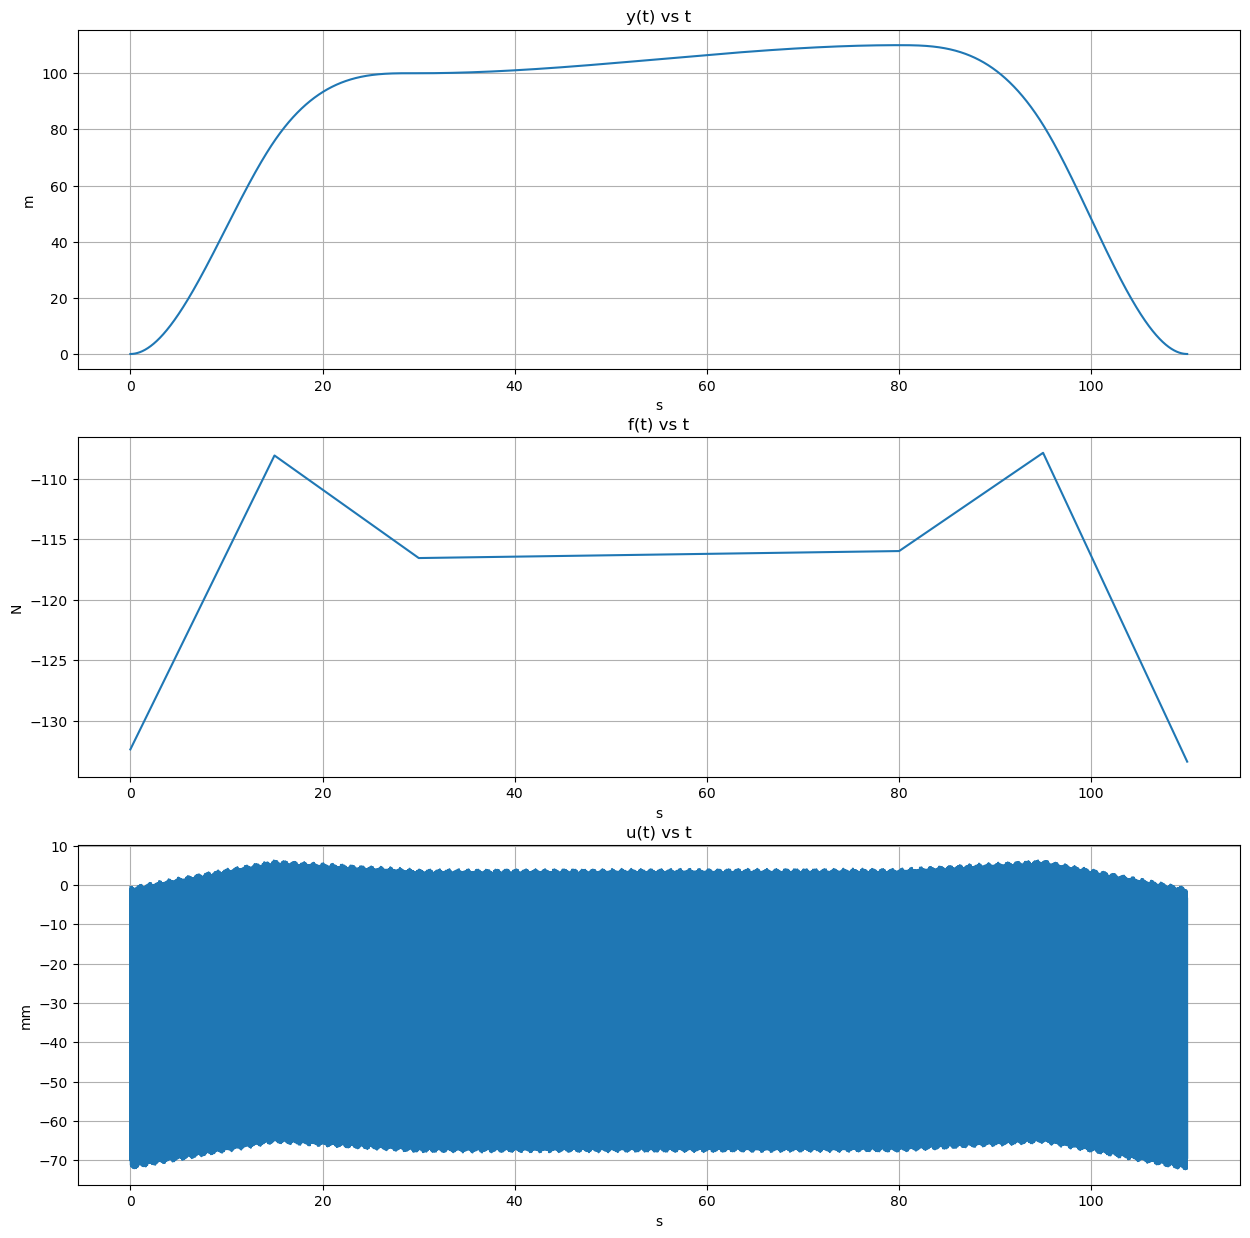

In [21]:

fig, axs = plt.subplots(3,1)

fig.set_figheight(15)
fig.set_figwidth(15)


axs[0].set_title("y(t) vs t")
axs[0].plot(list_t, y/1000)
axs[0].grid()
axs[0].set_ylabel("m")
axs[0].set_xlabel("s")

axs[1].set_title("f(t) vs t")
axs[1].plot(list_t, d1_fea.beam_system.z_forces_ts[:,2])
axs[1].grid()
axs[1].set_ylabel("N")
axs[1].set_xlabel("s")

axs[2].set_title("u(t) vs t")
axs[2].plot(list_t, d1_fea.beam_system.z_displacements_ts[:,2])
axs[2].grid()
axs[2].set_ylabel("mm")
axs[2].set_xlabel("s")

axs[3].set_title("Stress(t) vs t")
axs[3].plot(list_t, d1_fea.beam_system.z_displacements_ts[:,2])
axs[3].grid()
axs[3].set_ylabel("MPa")
axs[3].set_xlabel("s")




Text(0.5, 0, 's')

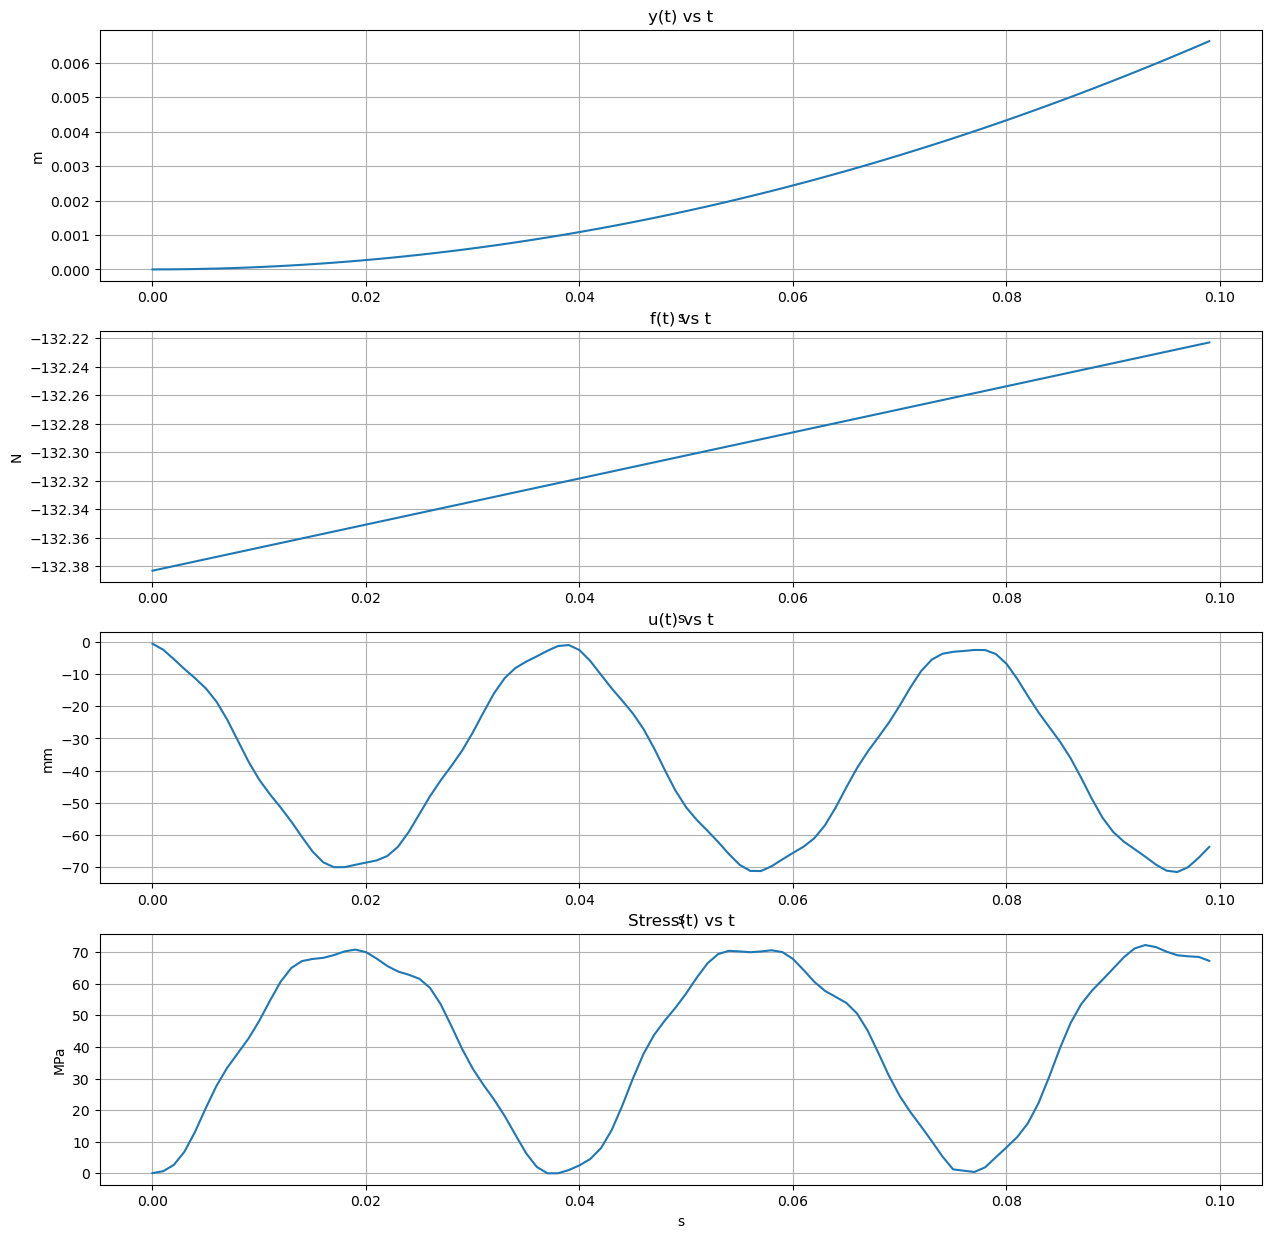

In [22]:
list_t = np.arange(0, m1.duration-q, q)


x = np.zeros(len(list_t))
y = np.zeros(len(list_t))
v_x = np.zeros(len(list_t))
v_y = np.zeros(len(list_t))
a_x = np.zeros(len(list_t))
a_y = np.zeros(len(list_t))

for i, t in enumerate(list_t):
    p, v, a = m1.time_solve(t)
    x[i] = p[0]
    y[i] = p[1]
    v_x[i] = v[0]
    v_y[i] = v[1]
    a_x[i] = a[0]
    a_y[i] = a[1]

fig, axs = plt.subplots(4,1)

fig.set_figheight(15)
fig.set_figwidth(15)


axs[0].set_title("y(t) vs t")
axs[0].plot(list_t[0:100], y[0:100]/1000)
axs[0].grid()
axs[0].set_ylabel("m")
axs[0].set_xlabel("s")

axs[1].set_title("f(t) vs t")
axs[1].plot(list_t[0:100], d1_fea.beam_system.z_forces_ts[:,2][0:100])
axs[1].grid()
axs[1].set_ylabel("N")
axs[1].set_xlabel("s")

axs[2].set_title("u(t) vs t")
axs[2].plot(list_t[0:100], d1_fea.beam_system.z_displacements_ts[:,2][0:100])
axs[2].grid()
axs[2].set_ylabel("mm")
axs[2].set_xlabel("s")


axs[3].set_title("Stress(t) vs t")
axs[3].plot(list_t[0:100], d1_fea.beam_system.beams[0].bending_stresses_0_ts[0:100])
axs[3].grid()
axs[3].set_ylabel("MPa")
axs[3].set_xlabel("s")


In [30]:
import numpy as np
import pandas as pd

import pylife.stress.timesignal as TS
import pylife.stress.rainflow as RF
import pylife.strength.meanstress as MS
import pylife.strength.fatigue

stress_curve = d1_fea.beam_system.beams[0].bending_stresses_0_ts

# No clue what this does something with rain counting
detector = RF.FourPointDetector(recorder=RF.LoopValueRecorder())
detector.process(stress_curve)

collective = detector.recorder.collective

print(collective)




ImportError: cannot import name copy_if_needed